In [58]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.utils import resample
from functools import partial

In [23]:
sys.path.append('..')

In [24]:
from vital.metrics import get_survival_metrics, get_risk_metrics, get_censoring_dist, include_exam_and_determine_label

In [25]:
# Import json file
with open("/tank-1/data/NLST/json/train_our_updated.json") as f:
    train_data = json.load(f)

with open("/tank-1/data/checkpoints/lung_survival/predictions_robust-bee-289.json") as f:
    data = json.load(f)

In [26]:
censoring_dist = get_censoring_dist(train_data)

In [27]:
censoring_dist

{'0': 0.9860950173812297,
 '1': 0.9764641732812178,
 '2': 0.9682088843711711,
 '3': 0.9618680525189961,
 '4': 0.9563014097865051,
 '5': 0.9507666066496202}

In [28]:
df = pd.DataFrame(data)
df.head()

,cancer_risk,gold,censors,pid,study,series,screen_timepoint,institution,cancer_laterality,y,time_at_event,y_seq,y_mask
0,"[0.02298833429813385, 0.08705801516771317, 0.0...",0,5,100005,1.2.840.113654.2.55.15354675073554904449223965...,1.2.840.113654.2.55.33065633377443331729120546...,0,A,"[4, False]",0,5,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1]"
1,"[0.01910572685301304, 0.07470250874757767, 0.0...",0,5,100005,1.2.840.113654.2.55.10251457513072085864761297...,1.2.840.113654.2.55.17324290215190661437113320...,1,A,"[4, False]",0,5,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1]"
2,"[0.018150808289647102, 0.06666027009487152, 0....",0,4,100005,1.2.840.113654.2.55.10940192540799808329280702...,1.2.840.113654.2.55.21247452796009259375851140...,2,A,"[4, False]",0,4,"[0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 0]"
3,"[0.8269565105438232, 0.8269565105438232, 0.826...",1,1,100012,1.2.840.113654.2.55.23803494144550801138646327...,1.2.840.113654.2.55.24023112856488152536348979...,0,A,"[4, False]",1,1,"[0, 1, 1, 1, 1, 1]","[1, 1, 0, 0, 0, 0]"
4,"[0.8621631860733032, 0.8621631860733032, 0.862...",1,0,100012,1.2.840.113654.2.55.38321092839390108338558865...,1.2.840.113654.2.55.50761756412482430061802871...,1,A,"[4, False]",1,0,"[1, 1, 1, 1, 1, 1]","[1, 0, 0, 0, 0, 0]"


In [29]:
probs = np.stack(df['cancer_risk'])
golds = np.stack(df['gold'])
censors = np.stack(df['censors'])
y = np.stack(df['y'])

In [30]:
get_survival_metrics(censors, probs, golds, censoring_dist, max_followup=6, mode="test")

{'test/1_year_auc': 0.922585933657577,
 'test/1_year_apscore': 0.4521040810537593,
 'test/1_year_prauc': 0.450058436956095,
 'test/2_year_auc': 0.8824486491909214,
 'test/2_year_apscore': 0.37729685899552584,
 'test/2_year_prauc': 0.37581453041596036,
 'test/3_year_auc': 0.8382158279533114,
 'test/3_year_apscore': 0.3348881882981539,
 'test/3_year_prauc': 0.33371276658860743,
 'test/4_year_auc': 0.8130773228755699,
 'test/4_year_apscore': 0.3057990374419278,
 'test/4_year_prauc': 0.30477884880896455,
 'test/5_year_auc': 0.8014689146520998,
 'test/5_year_apscore': 0.31398359563553896,
 'test/5_year_prauc': 0.313112146313037,
 'test/6_year_auc': 0.8016440868507584,
 'test/6_year_apscore': 0.3757326195534046,
 'test/6_year_prauc': 0.3749988607236215,
 'test/c_index': 0.7948569437552315}

In [31]:
get_risk_metrics(censors, probs, golds, max_followup=6, mode="test")

/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


{'test/1_year_risk_auc': nan,
 'test/1_year_risk_apscore': 0.0,
 'test/1_year_risk_prauc': 0.5,
 'test/2_year_risk_auc': 0.8204532284513051,
 'test/2_year_risk_apscore': 0.05724655430487347,
 'test/2_year_risk_prauc': 0.0510794538476324,
 'test/3_year_risk_auc': 0.7686110431963908,
 'test/3_year_risk_apscore': 0.07584962501789341,
 'test/3_year_risk_prauc': 0.07165234554033205,
 'test/4_year_risk_auc': 0.7505538841985024,
 'test/4_year_risk_apscore': 0.08313891646020066,
 'test/4_year_risk_prauc': 0.08003776934088723,
 'test/5_year_risk_auc': 0.7485840497651215,
 'test/5_year_risk_apscore': 0.11276056980713384,
 'test/5_year_risk_prauc': 0.10941425382359854,
 'test/6_year_risk_auc': 0.7546732737088067,
 'test/6_year_risk_apscore': 0.17318335728642786,
 'test/6_year_risk_prauc': 0.17159852364266415}

# Bootstrap CI values

In [73]:
from sklearn.utils import resample

# Wrap this for loop into a function
def bootstrap_metric_scores(n_bootstrap, metric_func, censors, probs, golds, y):
    bootstrap_scores = []
    for i in range(n_bootstrap):
        # Bootstrap resample
        indices = resample(range(len(probs)), random_state=i)
        c = censors[indices]
        g = golds[indices]
        p = probs[indices, :]
        y = y[indices]

        # Calculate metric on bootstrap sample
        score = metric_func(c, p, g)
        bootstrap_scores.append(score)
    return bootstrap_scores

# Convert list of dictionaries to dictionary of numpy arrays
def convert_bootstrap_scores(bootstrap_scores):
    """
    Convert list of score dictionaries to dictionary of numpy arrays
    
    Args:
        bootstrap_scores: List of dictionaries, each containing metric scores
        
    Returns:
        Dictionary with same keys but numpy arrays as values
    """
    if not bootstrap_scores:
        return {}
    
    # Get all metric names from first dictionary
    metric_names = bootstrap_scores[0].keys()
    
    # Convert to arrays
    score_arrays = {}
    for metric in metric_names:
        scores = [score_dict[metric] for score_dict in bootstrap_scores]
        score_arrays[metric] = np.array(scores)
    
    return score_arrays

# Calculate median and confidence intervals
def calculate_ci(bootstrap_scores, ci_level=0.95):
    """
    Calculate median and confidence intervals from bootstrap scores
    
    Args:
        bootstrap_scores: List of score dictionaries or dict of arrays
        ci_level: Confidence level (default 0.95 for 95% CI)
        
    Returns:
        Dictionary with median, lower_ci, upper_ci for each metric
    """
    # Convert if needed
    if isinstance(bootstrap_scores, list):
        score_arrays = convert_bootstrap_scores(bootstrap_scores)
    else:
        score_arrays = bootstrap_scores
    
    results = {}
    alpha = 1 - ci_level
    
    for metric, scores in score_arrays.items():
        # Handle NaN values
        valid_scores = scores[~np.isnan(scores)]
        
        if len(valid_scores) > 0:
            median = np.median(valid_scores)
            lower_ci = np.percentile(valid_scores, 100 * alpha/2)
            upper_ci = np.percentile(valid_scores, 100 * (1 - alpha/2))
            
            results[metric] = {
                'median': median,
                'lower_ci': lower_ci,
                'upper_ci': upper_ci,
                'n_valid': len(valid_scores)
            }
        else:
            results[metric] = {
                'median': np.nan,
                'lower_ci': np.nan,
                'upper_ci': np.nan,
                'n_valid': 0
            }
    
    return results

In [74]:
def format_ci_results_table(ci_results):
    """
    Convert CI results to a formatted table grouped by metric type
    """
    # Organize data by metric type and year
    table_data = []
    
    for metric_name, stats in ci_results.items():
        if stats['n_valid'] == 0:
            continue
            
        # Parse metric name
        parts = metric_name.split('/')
        if len(parts) == 2:
            prefix, metric_year = parts
            # Extract year and metric type
            if '_year_' in metric_year:
                year_part, metric_type = metric_year.split('_year_')
                year = int(year_part)
            else:
                year = 'Overall'
                metric_type = metric_year
        else:
            year = 'Overall'
            metric_type = metric_name
            
        table_data.append({
            'Metric Type': metric_type.upper(),
            'Year': year,
            'Median': f"{stats['median']:.3f}",
            '95% CI': f"({stats['lower_ci']:.3f}-{stats['upper_ci']:.3f})",
            'N Valid': stats['n_valid']
        })
    
    # Create DataFrame and sort
    df = pd.DataFrame(table_data)
    df = df.sort_values(['Metric Type', 'Year'])
    
    return df

In [ ]:
# Wrap the whole cell ina function

def run_bootstrap_analysis(n_bootstrap, metric_func, censors, probs, golds, y):
    bootstrap_scores = bootstrap_metric_scores(n_bootstrap, metric_func, censors, probs, golds, y)
    bootstrap_scores = convert_bootstrap_scores(bootstrap_scores)
    ci_results = calculate_ci(bootstrap_scores, ci_level=0.95)

    # Create and display the table
    results_table = format_ci_results_table(ci_results)
    print("Bootstrap Confidence Intervals (95% CI)")
    print("=" * 50)
    print(results_table.to_string(index=False))

    # # Optional: Group by metric type for better readability
    # print("\n\nGrouped by Metric Type:")
    # print("=" * 50)
    # for metric_type in results_table['Metric Type'].unique():
    #     print(f"\n{metric_type}:")
    #     subset = results_table[results_table['Metric Type'] == metric_type]
    #     print(subset[['Year', 'Median', '95% CI']].to_string(index=False))

## Survival Metrics

In [80]:
# Usage with your bootstrap_scores
n_bootstrap = 1000
metric_func = partial(get_survival_metrics, censoring_distribution=censoring_dist, max_followup=6, mode="test")  # Change this to the desired metric function
run_bootstrap_analysis(n_bootstrap, metric_func, censors, probs, golds, y)

Bootstrap Confidence Intervals (95% CI)
Metric Type    Year Median        95% CI  N Valid
    APSCORE       1  0.454 (0.345-0.555)     1000
    APSCORE       2  0.379 (0.290-0.461)     1000
    APSCORE       3  0.337 (0.265-0.408)     1000
    APSCORE       4  0.308 (0.246-0.371)     1000
    APSCORE       5  0.316 (0.261-0.369)     1000
    APSCORE       6  0.377 (0.319-0.429)     1000
        AUC       1  0.923 (0.885-0.953)     1000
        AUC       2  0.883 (0.853-0.909)     1000
        AUC       3  0.839 (0.808-0.867)     1000
        AUC       4  0.813 (0.785-0.840)     1000
        AUC       5  0.801 (0.773-0.827)     1000
        AUC       6  0.801 (0.776-0.827)     1000
    C_INDEX Overall  0.794 (0.769-0.820)     1000
      PRAUC       1  0.450 (0.338-0.552)     1000
      PRAUC       2  0.376 (0.286-0.458)     1000
      PRAUC       3  0.335 (0.262-0.406)     1000
      PRAUC       4  0.306 (0.244-0.369)     1000
      PRAUC       5  0.314 (0.259-0.368)     1000
      PRAU

## Risk metrics

In [81]:
# Risk metrics
n_bootstrap = 1000
metric_func = partial(get_risk_metrics, max_followup=6, mode="test")  # Change this to the desired metric function
run_bootstrap_analysis(n_bootstrap, metric_func, censors, probs, golds, y)

/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresh

/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresh

Bootstrap Confidence Intervals (95% CI)
 Metric Type  Year Median        95% CI  N Valid
RISK_APSCORE     1  0.000 (0.000-0.000)     1000
RISK_APSCORE     2  0.062 (0.028-0.128)     1000
RISK_APSCORE     3  0.080 (0.047-0.131)     1000
RISK_APSCORE     4  0.087 (0.058-0.128)     1000
RISK_APSCORE     5  0.116 (0.085-0.154)     1000
RISK_APSCORE     6  0.176 (0.136-0.220)     1000
    RISK_AUC     2  0.821 (0.769-0.865)     1000
    RISK_AUC     3  0.769 (0.725-0.816)     1000
    RISK_AUC     4  0.751 (0.712-0.789)     1000
    RISK_AUC     5  0.748 (0.714-0.781)     1000
    RISK_AUC     6  0.755 (0.721-0.786)     1000
  RISK_PRAUC     1  0.500 (0.500-0.500)     1000
  RISK_PRAUC     2  0.052 (0.024-0.112)     1000
  RISK_PRAUC     3  0.073 (0.044-0.122)     1000
  RISK_PRAUC     4  0.081 (0.055-0.119)     1000
  RISK_PRAUC     5  0.112 (0.081-0.150)     1000
  RISK_PRAUC     6  0.173 (0.133-0.217)     1000


/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/tank-1/users/chev/lung/.venv/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


# TPR at x FPR and Precision at x Recall

In [32]:
def get_probs_and_golds(probs, censor_times, golds, followup, fup_lower_bound=-1):
    probs_for_eval = []
    golds_for_eval = []
    for prob_arr, censor_time, gold in zip(probs, censor_times, golds):
        include, label = include_exam_and_determine_label(censor_time, gold, followup, fup_lower_bound)
        if include:
            probs_for_eval.append(prob_arr[followup])
            golds_for_eval.append(label)
    return probs_for_eval, golds_for_eval



# FUP lower bound
## Survival
default value = -1

## Risk
value = 0

In [33]:
def get_tpr_at_fpr(probs, censors, golds, fpr_target=0.1, fup_lower_bound=-1):
    tpr_list = []
    for i in range(6):
        p, g = get_probs_and_golds(probs, censors, golds, i, fup_lower_bound)
        # Get TPR at x FPR
        fpr, tpr, _ = roc_curve(np.array(g), np.array(p))
        tpr_val = tpr[np.where(fpr <= fpr_target)[0][-1]]
        tpr_list.append(tpr_val)
    return tpr_list

def get_precision_at_recall(probs, censors, golds, recall_target=0.8):
    precision_list = []
    for i in range(6):
        p, g = get_probs_and_golds(probs, censors, golds, i,    fup_lower_bound=-1)
        # Get precision at x recall
        precision, recall, _ = precision_recall_curve(np.array(g), np.array(p))
        precision_val = precision[np.where(recall >= recall_target)[0][-1]]
        precision_list.append(precision_val)
    return precision_list
    

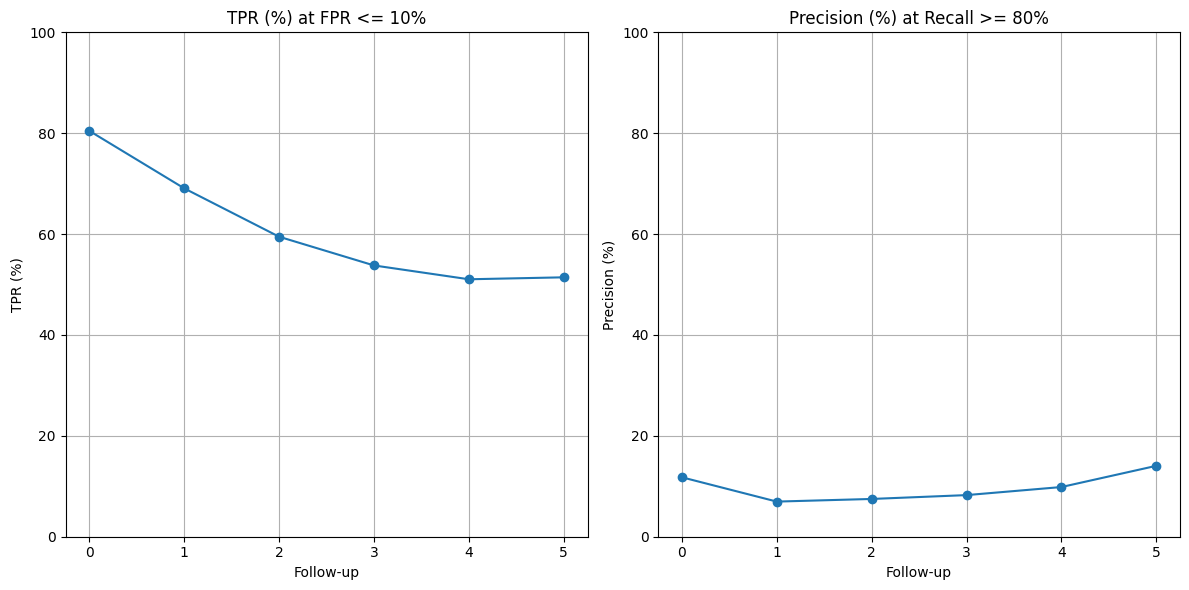

TPR (%) values at FPR <= 10.0%: [80.45977011494253, 69.06474820143885, 59.473684210526315, 53.78151260504202, 51.041666666666664, 51.42857142857142]
Precision (%) values at Recall >= 80.0%: [11.784511784511785, 6.965174129353234, 7.48768472906404, 8.250539956803456, 9.850746268656717, 14.054656999442274]


In [34]:
# Plot tprs at fpr and precisions at recall grapphs. Two different graphs. for followup 0 to 5. Add grids to the plots.

import matplotlib.pyplot as plt

fpr_target = 0.1
recall_target = 0.8

tpr_values = get_tpr_at_fpr(probs, censors, golds, fpr_target)
precision_values = get_precision_at_recall(probs, censors, golds, recall_target)

# Convert decimals to percentages
tpr_percent = [v * 100 if v is not None else None for v in tpr_values]
precision_percent = [v * 100 if v is not None else None for v in precision_values]

# Plot TPR at FPR
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(6), tpr_percent, marker='o')
plt.title(f'TPR (%) at FPR <= {fpr_target*100:.0f}%')
plt.xlabel('Follow-up')
plt.ylabel('TPR (%)')
plt.xticks(range(6))
plt.ylim(0, 100)
plt.grid()  # Add grid to first plot

# Plot Precision at Recall
plt.subplot(1, 2, 2)
plt.plot(range(6), precision_percent, marker='o')
plt.title(f'Precision (%) at Recall >= {recall_target*100:.0f}%')
plt.xlabel('Follow-up')
plt.ylabel('Precision (%)')
plt.xticks(range(6))
plt.ylim(0, 100)
plt.grid()  # Add grid to second plot

plt.tight_layout()
plt.show()

print("TPR (%) values at FPR <= {}%: {}".format(fpr_target*100, tpr_percent))
print("Precision (%) values at Recall >= {}%: {}".format(recall_target*100, precision_percent))

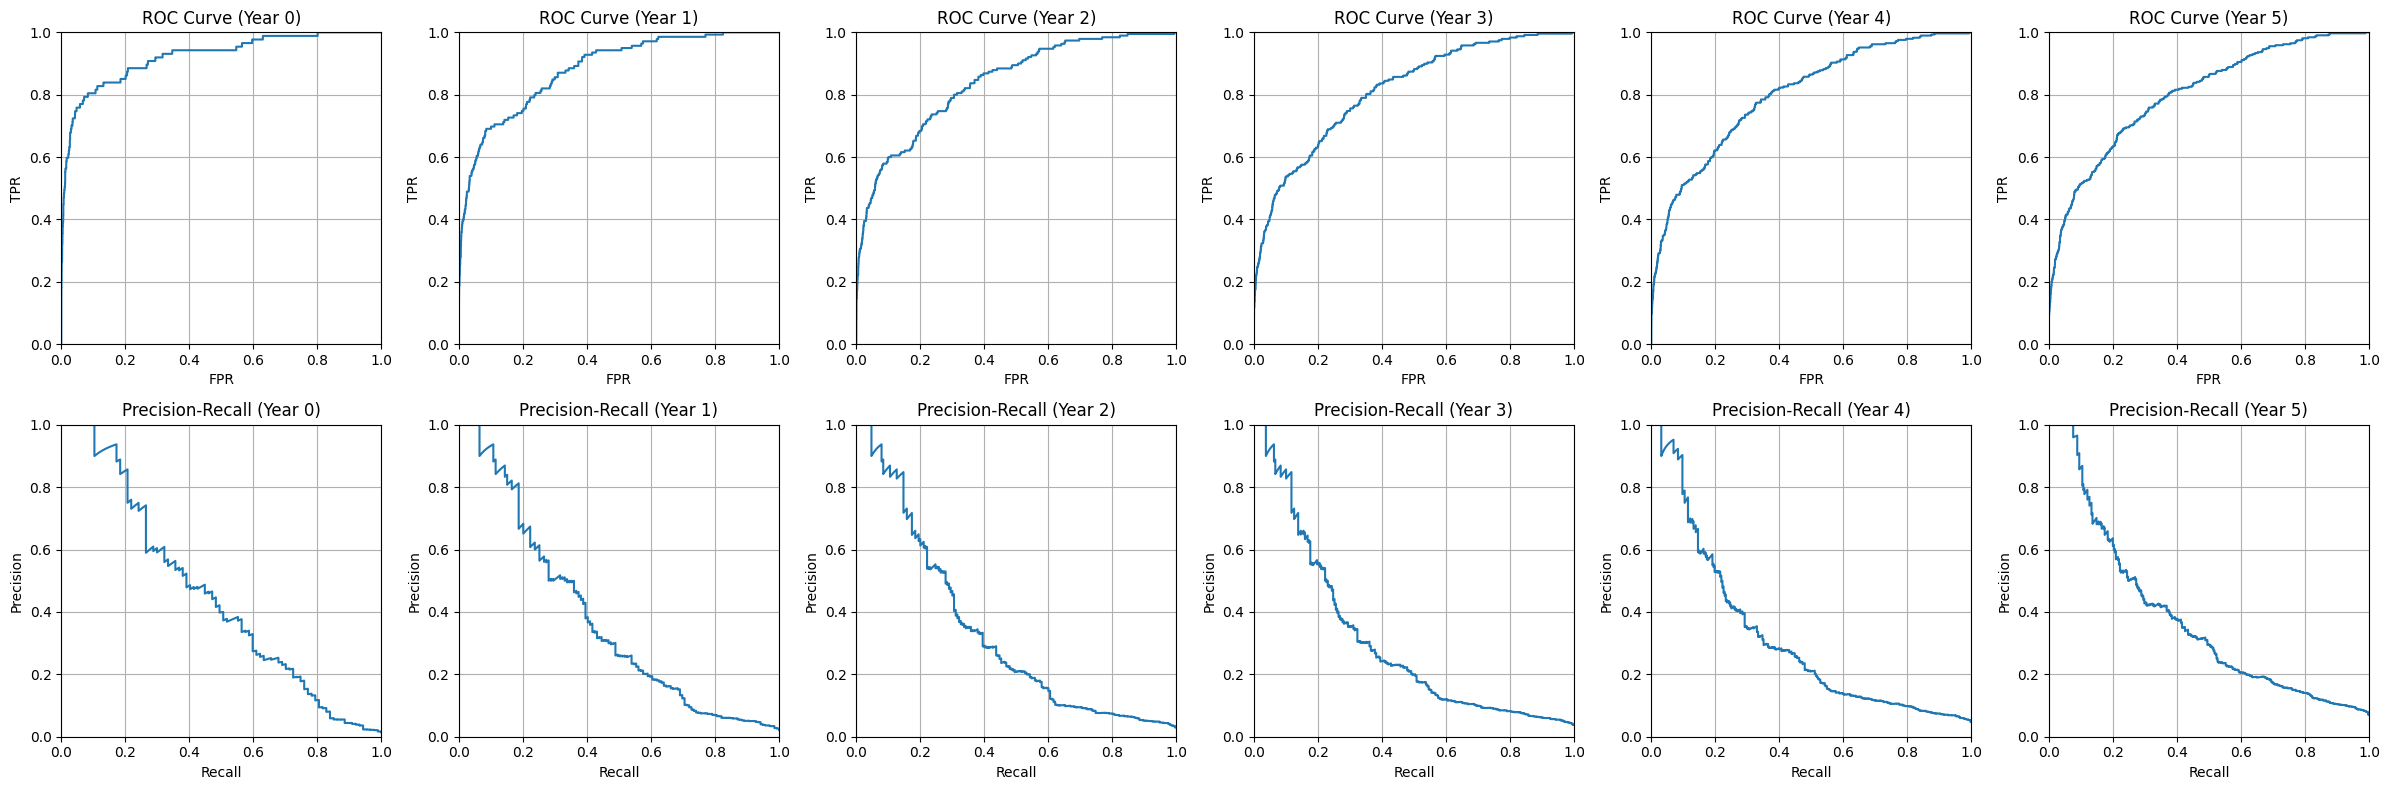

In [35]:
# Plot ROC and Precision-Recall curves for all followup years
fig, axes = plt.subplots(2, 6, figsize=(24, 8))
for i in range(6):
    # Get data for this followup year
    p, g = get_probs_and_golds(probs, censors, golds, i)
    # ROC curve
    fpr, tpr, _ = roc_curve(np.array(g), np.array(p))
    axes[0, i].plot(fpr, tpr, label=f'Year {i}')
    axes[0, i].set_title(f'ROC Curve (Year {i})')
    axes[0, i].set_xlabel('FPR')
    axes[0, i].set_ylabel('TPR')
    axes[0, i].set_xlim(0, 1)
    axes[0, i].set_ylim(0, 1)
    axes[0, i].grid()
    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(np.array(g), np.array(p))
    axes[1, i].plot(recall, precision, label=f'Year {i}')
    axes[1, i].set_title(f'Precision-Recall (Year {i})')
    axes[1, i].set_xlabel('Recall')
    axes[1, i].set_ylabel('Precision')
    axes[1, i].set_xlim(0, 1)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].grid()
plt.tight_layout()
plt.show()

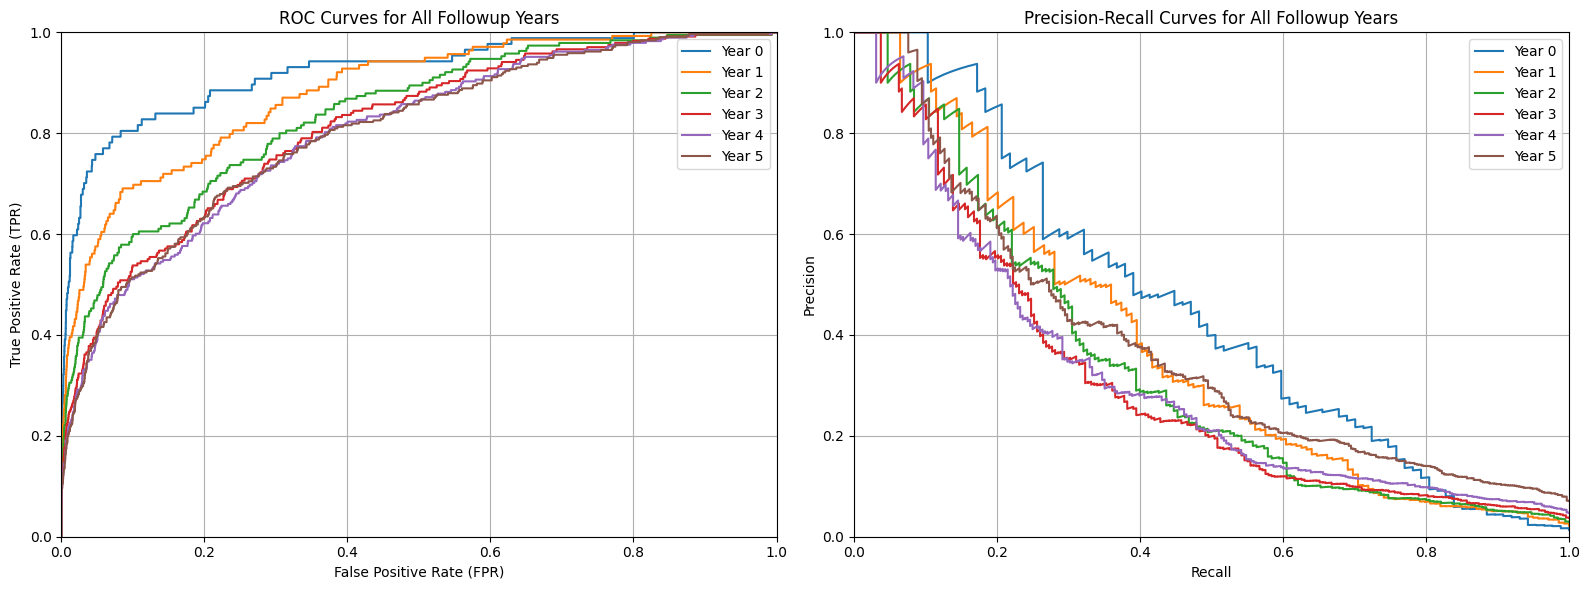

In [36]:
# Plot ROC and Precision-Recall curves for all followup years side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i in range(6):
    p, g = get_probs_and_golds(probs, censors, golds, i)
    fpr, tpr, _ = roc_curve(np.array(g), np.array(p))
    axes[0].plot(fpr, tpr, label=f'Year {i}')
axes[0].set_title('ROC Curves for All Followup Years')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid()
for i in range(6):
    p, g = get_probs_and_golds(probs, censors, golds, i)
    precision, recall, _ = precision_recall_curve(np.array(g), np.array(p))
    axes[1].plot(recall, precision, label=f'Year {i}')
axes[1].set_title('Precision-Recall Curves for All Followup Years')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid()
plt.tight_layout()
plt.show()

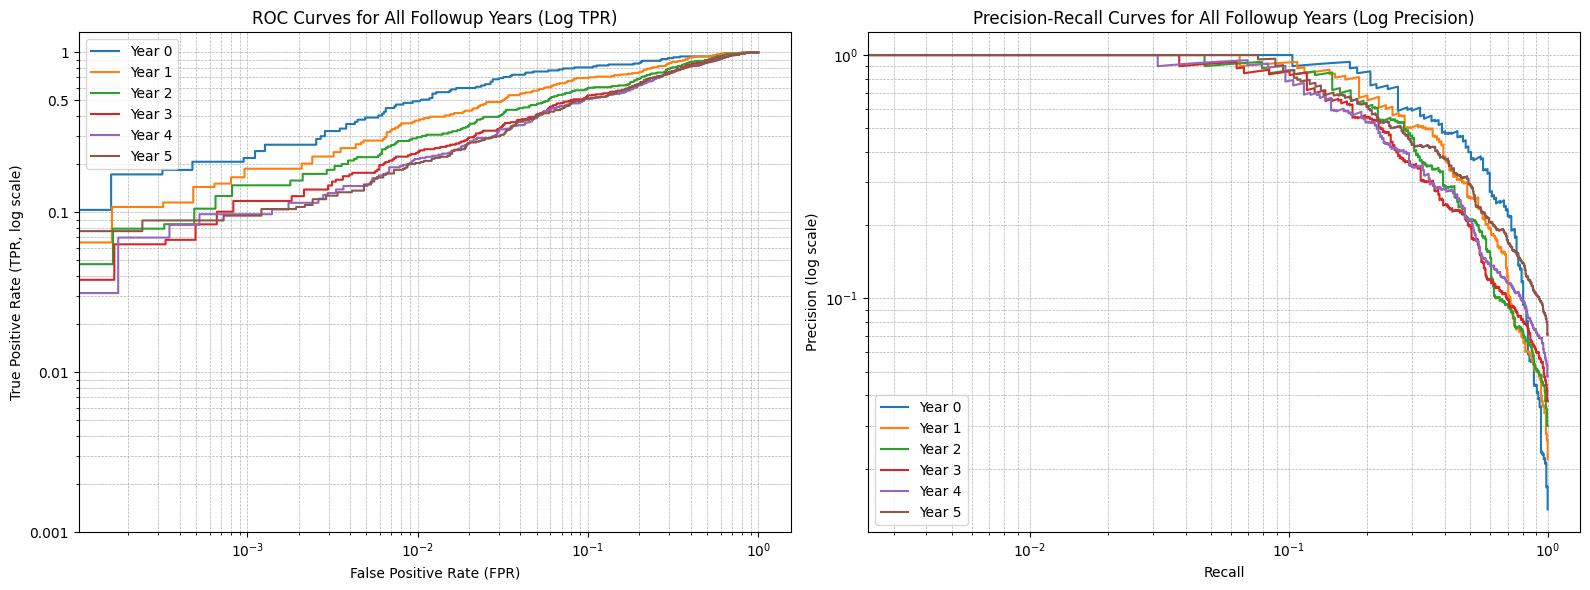

In [37]:
# Plot ROC and Precision-Recall curves for all followup years side by side with log-scaled y-axes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i in range(6):
    p, g = get_probs_and_golds(probs, censors, golds, i)
    fpr, tpr, _ = roc_curve(np.array(g), np.array(p))
    axes[0].plot(fpr, tpr, label=f'Year {i}')
axes[0].set_title('ROC Curves for All Followup Years (Log TPR)')
axes[0].set_xlabel('False Positive Rate (FPR)')
axes[0].set_ylabel('True Positive Rate (TPR, log scale)')
# axes[0].set_xlim(0, 1)
# axes[0].set_ylim(1e-1, 1)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(which='both', linestyle='--', linewidth=0.5)
axes[0].set_yticks([0.001, 0.01, 0.1, 0.5, 1])
axes[0].set_yticklabels(['0.001', '0.01', '0.1', '0.5', '1'])
for i in range(6):
    p, g = get_probs_and_golds(probs, censors, golds, i)
    precision, recall, _ = precision_recall_curve(np.array(g), np.array(p))
    axes[1].plot(recall, precision, label=f'Year {i}')
axes[1].set_title('Precision-Recall Curves for All Followup Years (Log Precision)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision (log scale)')
# axes[1].set_xlim(0, 1)
# axes[1].set_ylim(1e-3, 1)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(which='both', linestyle='--', linewidth=0.5)
# axes[1].set_yticks([0.001, 0.01, 0.1, 0.5, 1])
# axes[1].set_yticklabels(['0.001', '0.01', '0.1', '0.5', '1'])
plt.tight_layout()
plt.show()